NAME: KRRISH GULERIA ---  ASSIGN : 02 --- ML

In [153]:
#import necessary libraries
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


In [154]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/My Drive/CDAC_2026_ML/ASSIGNMENT/data - data.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Section 1: Data Loading &amp; Exploratory Data Analysis
(EDA)

In [155]:
#Q1. Load the Wisconsin Breast Cancer dataset using pandas and display the first 5 rows.
#What is the shape of the dataset? Check the column names and data types.

print("First 5 rows: \n")
print(df.head(5))
print()

print("Shape of dataset: ")
print(df.shape)
print()

print("Columns of dataset: ")
print(df.columns)
print()


print("Dtypes of dataset: ")
print(df.dtypes)
print()

First 5 rows: 

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter

Diagnosis Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64

Percentage Distribution:
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


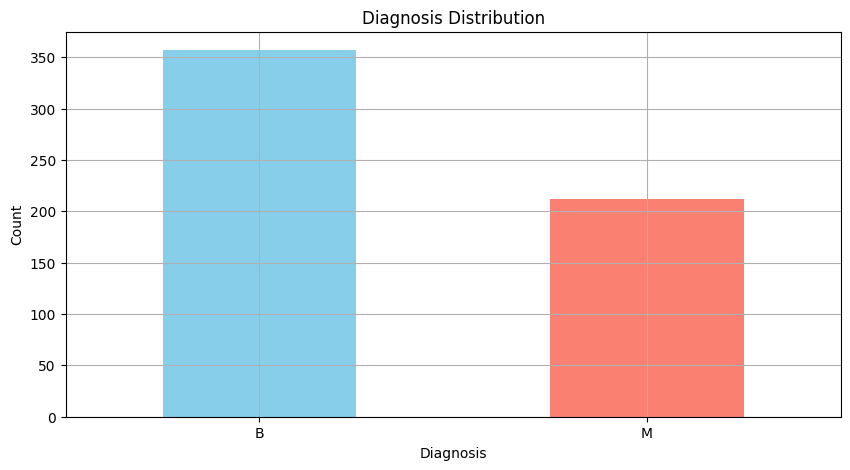

In [156]:
#Q2. Check the target variable diagnosis distribution:

#1 Count of Malignant (M) vs Benign (B) cases

diagnosis_cnt = df['diagnosis'].value_counts()

print("Diagnosis Distribution:")
print(diagnosis_cnt)

#2 Percentage of each class

diagnosis_percent = df['diagnosis'].value_counts(normalize=True) * 100

print("\nPercentage Distribution:")
print(diagnosis_percent)


#3 Is the dataset balanced or imbalanced? Use value_counts() and plot() to visualize.

plt.figure(figsize=(10,5))
df['diagnosis'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.title("Diagnosis Distribution")
plt.xticks(rotation = 0)
plt.grid()
plt.show()

In [157]:
#Q3. Calculate descriptive statistics for all 30 numerical features using describe(). Identify:

stats= df.describe()
print(stats)

#1 Which feature has the highest mean value?

high_mean = stats.loc['mean'].idxmax()
print("Feature with highest mean:", high_mean)
print("Mean Value:", stats.loc['mean', high_mean])
print()


#2 Which feature has the highest standard deviation?

high_std = stats.loc['std'].idxmax()
print("Feature with highest std:", high_std)
print("Std Value:", stats.loc['std', high_std])
print()

#3 Are there any features with very low variance (close to 0)?

low_var = df.drop(columns=['id','diagnosis']).var()
low_variance = low_var[low_var <0.01]
print("\nFeatures with very low variance:")
print(low_variance)

                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813     

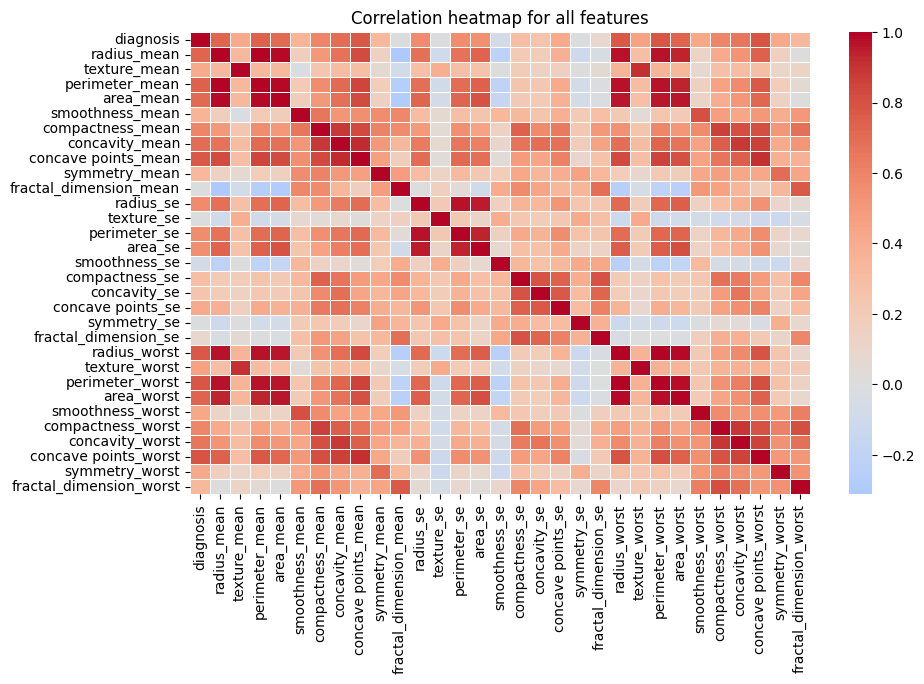

In [158]:
#Q4. Create a correlation heatmap for all features using seaborn. Identify:
#1 Which 3 features have the highest correlation with diagnosis?
#2 Which features are highly correlated with each other (correlation &gt; 0.8)? Suggest
#potential feature removal.

# Convert diagnosis to numeric
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})


corr_matrix = df.drop(columns=['id']).corr()
plt.figure(figsize=(10,6))
sns.heatmap(
    corr_matrix,
    cmap= "coolwarm",
    center=0, linewidths=0.5
)
plt.title("Correlation heatmap for all features")
plt.show()

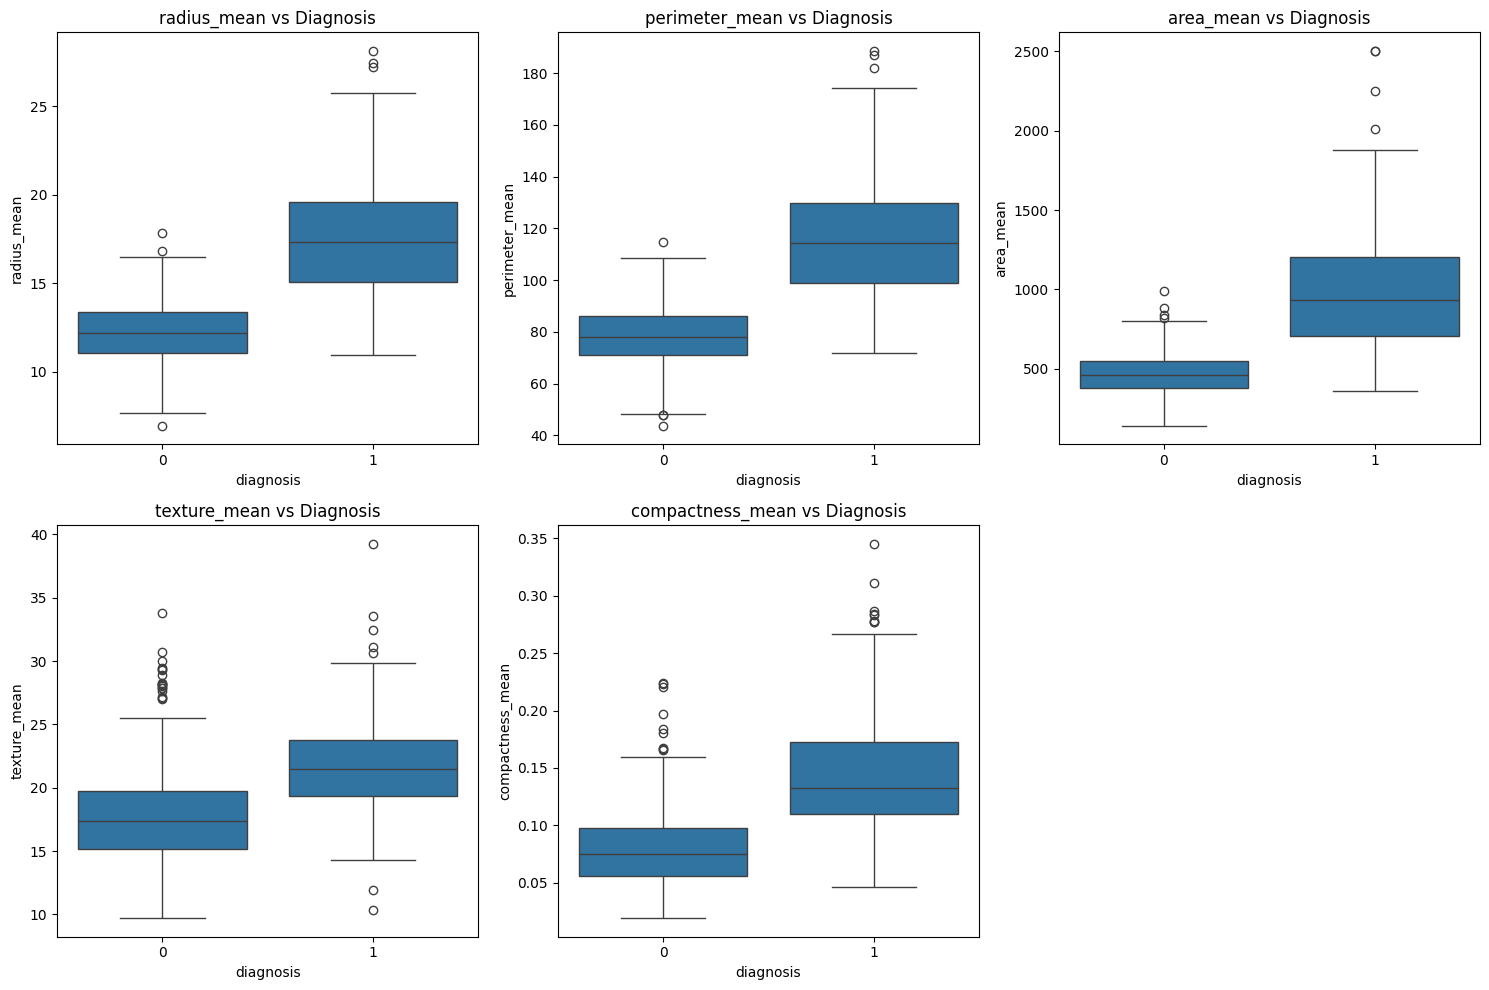

In [159]:
#Q5. Create box plots for the top 5 features most correlated with diagnosis (radius_mean,
#perimeter_mean, area_mean, texture_mean, compactness_mean). What patterns do you
#observe between Malignant and Benign cases?

features = ['radius_mean','perimeter_mean','area_mean','texture_mean','compactness_mean']

plt.figure(figsize=(15,10))

for i, feature in enumerate(features, 1):
  plt.subplot(2,3,i)
  sns.boxplot(x='diagnosis', y= feature, data=df)
  plt.title(f"{feature} vs Diagnosis")

plt.tight_layout()
plt.show()

#Ans: Pattern that i see is the malignant tumors generally have higher values of radius, perimeter, area, and compactness than benign tumors which indicates they are larger and more irregular.
#Among these features, area_mean shows the clearest separation between malignant and benign cases.

Section 2: Data Preprocessing`

In [160]:
#Q6. Convert the target variable diagnosis from categorical to numerical:
#1 Malignant (M) = 1
#2 Benign (B) = 0
#Use map() or replace() and verify the transformation.

#df['diagnosis'] = df['diagnosis'].map({
    #'M':1, 'B': 0
#})  ---> as i earlier map in previous heatmap stage

#verify transformation
print(df['diagnosis'].head())
print(df['diagnosis'].value_counts())

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64
diagnosis
0    357
1    212
Name: count, dtype: int64


In [161]:
#Q7. Check for missing values in the dataset using isnull().sum(). If any missing values
#exist, handle them appropriately (drop rows or fill with mean/median).

print("Check for missing values: ")
print(df.isnull().sum())



Check for missing values: 
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [162]:
#no missing values found to again verify:

df.isnull().sum().sum()

np.int64(0)

In [163]:
#Q8. Split the dataset into features (X) and target (y). Then apply Train-Test split:
#1 80% training, 20% testing
#2 Stratify by target variable (to maintain class distribution)
#3 Use random_state = 42
#Display the shape of X_train, X_test, y_train, y_test.

X = df.drop(columns=['id', 'diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (455, 30)
X_test shape : (114, 30)
y_train shape: (455,)
y_test shape : (114,)


In [164]:
#Q9. Apply Standardization on features using StandardScaler:
#1 Scale only the training data (fit_transform)
#2 Transform test data using training scaler (transform)
#Why is standardization important for SVM? Display the first 5 rows of scaled training
#data.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display first 5 rows of scaled training data
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

print(X_train_scaled_df.head())

   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0    -1.440753     -0.435319       -1.362085  -1.139118         0.780573   
1     1.974096      1.733026        2.091672   1.851973         1.319843   
2    -1.399982     -1.249622       -1.345209  -1.109785        -1.332645   
3    -0.981797      1.416222       -0.982587  -0.866944         0.059390   
4    -1.117700     -1.010259       -1.125002  -0.965942         1.269511   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0          0.718921        2.823135            -0.119150       1.092662   
1          3.426275        2.013112             2.665032       2.127004   
2         -0.307355       -0.365558            -0.696502       1.930333   
3         -0.596788       -0.820203            -0.845115       0.313264   
4         -0.439002       -0.983341            -0.930600       3.394436   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0           

Section 3: SVM (Support Vector Machine)

In [165]:
#Q10. Implement SVM with Linear Kernel:

#1 Use SVC(kernel='linear', random_state=42)

svm_linear = SVC(
    kernel='linear',
    random_state=42,
    probability=True
)

#2 Train on scaled training data

svm_linear.fit(X_train_scaled, y_train)

#3 Predict on test data

y_pred = svm_linear.predict(X_test_scaled)

# Probability predictions for ROC-AUC
y_prob = svm_linear.predict_proba(X_test_scaled)[:, 1]


#4 Calculate Accuracy, Precision, Recall, F1-Score, and ROC-AUC

accuracy_lsvm = accuracy_score(y_test, y_pred)
precision_lsvm = precision_score(y_test, y_pred)
recall_lsvm = recall_score(y_test, y_pred)
f1_lsvm = f1_score(y_test, y_pred)
roc_auc_lsvm = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy_lsvm)
print("Precision:", precision_lsvm)
print("Recall   :", recall_lsvm)
print("F1 Score :", f1_lsvm)
print("ROC-AUC  :", roc_auc_lsvm)


# Confusion Matrix
cm_lsvm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm_lsvm)

Accuracy : 0.956140350877193
Precision: 0.9318181818181818
Recall   : 0.9534883720930233
F1 Score : 0.9425287356321839
ROC-AUC  : 0.9963969865705863

Confusion Matrix:
[[68  3]
 [ 2 41]]


In [166]:
#Q11. Implement SVM with RBF Kernel (Recommended):
#1 Use SVC(kernel='rbf', C=1, gamma=0.1, random_state=42)

svm_rbf = SVC(
    kernel='rbf', C=1, gamma=0.1, random_state=42, probability= True
)

#2 Train and predict

svm_rbf.fit(X_train_scaled, y_train)

# Predictions
y_pred_rbf = svm_rbf.predict(X_test_scaled)
y_prob_rbf = svm_rbf.predict_proba(X_test_scaled)[:,1]


#3 Calculate the same metrics as Q10

accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
precision_rbf = precision_score(y_test, y_pred_rbf)
recall_rbf = recall_score(y_test, y_pred_rbf)
f1_rbf = f1_score(y_test, y_pred_rbf)
roc_auc_rbf = roc_auc_score(y_test, y_prob_rbf)


print("Accuracy :", accuracy_rbf)
print("Precision:", precision_rbf)
print("Recall   :", recall_rbf)
print("F1 Score :", f1_rbf)
print("ROC-AUC  :", roc_auc_rbf)

# Confusion Matrix
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

print("\nConfusion Matrix:")
print(cm_rbf)

#4 Compare Linear vs RBF kernel performance. Which is better? Why?

#ANS: The RBF Kernel SVM performs slightly better overall because it achieves:
#Higher Accuracy (96.49%)
#Higher Precision (95.35%)
#Higher F1-Score (95.35%)
#Same Recall as Linear SVM

#but, the Linear SVM has a slightly higher ROC-AUC than rbf svm (99.64% vs 98.89%), indicating excellent class separation.



Accuracy : 0.9649122807017544
Precision: 0.9534883720930233
Recall   : 0.9534883720930233
F1 Score : 0.9534883720930233
ROC-AUC  : 0.9888634130363577

Confusion Matrix:
[[69  2]
 [ 2 41]]


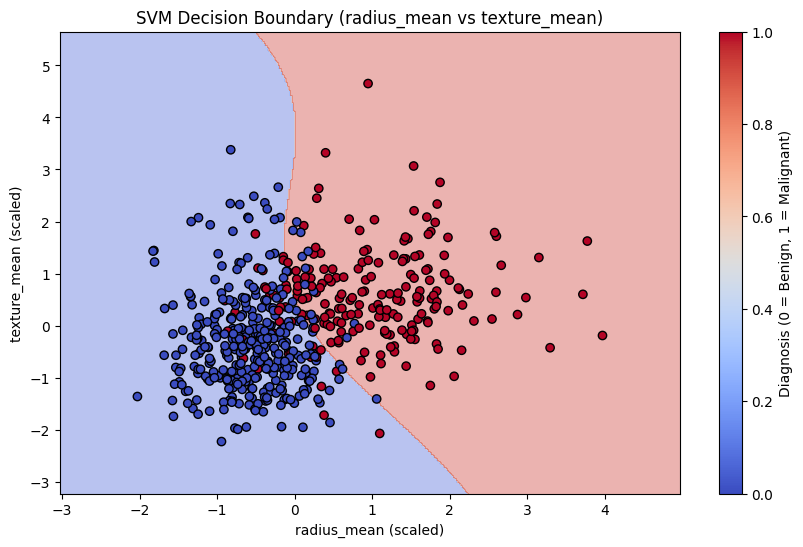

In [167]:
#Q12. Visualize SVM decision boundary (use only 2 features for visualization):

#1 Select top 2 features: radius_mean and texture_mean

X = df[['radius_mean', 'texture_mean']]
y = df['diagnosis']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#2 Train SVM on these 2 features

svm = SVC(kernel='rbf', C=1, gamma=0.1, random_state=42)
svm.fit(X_scaled, y)


#3 Create a mesh grid to plot decision surface

x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)


Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision surface
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')

#4 Plot training points with decision boundary

scatter = plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=y,
    cmap='coolwarm',
    edgecolors='black'
)

plt.xlabel("radius_mean (scaled)")
plt.ylabel("texture_mean (scaled)")
plt.title("SVM Decision Boundary (radius_mean vs texture_mean)")


#5 Add color bar for classes

cbar = plt.colorbar(scatter)
cbar.set_label("Diagnosis (0 = Benign, 1 = Malignant)")

plt.show()



Section 4: CART (Decision Tree)

In [168]:
#Q13. Implement Decision Tree Classifier (CART):

# Use DecisionTreeClassifier(max_depth=5, random_state=42)

dt = DecisionTreeClassifier(
    max_depth=5, random_state=42
)

# Train on scaled training data

dt.fit(X_train_scaled, y_train)

# Predict on test data

y_pred_dt = dt.predict(X_test_scaled)

# Probability predictions for ROC-AUC
y_prob_dt = dt.predict_proba(X_test_scaled)[:, 1]


# Calculate Accuracy, Precision, Recall, F1-Score, ROC-AUC

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

# Display confusion matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)
print("ROC-AUC  :", roc_auc_dt)

print("\nConfusion Matrix:")
print(cm_dt)
print()
# Compare with SVM results. Which model performs better?

compare = pd.DataFrame({
    "Metric": ['Linear SVM', 'RBF SVM', 'Decision Tree'],
    "Accuracy": [accuracy_lsvm, accuracy_rbf, accuracy_dt],
    "Precision":[precision_lsvm, precision_rbf, precision_dt],
    "Recall":[recall_lsvm, recall_rbf, recall_dt],
    "F1 Score":[f1_lsvm, f1_rbf, f1_dt],
    "roc-auc":[roc_auc_lsvm, roc_auc_rbf, roc_auc_dt]
})
print(compare)

Accuracy : 0.9473684210526315
Precision: 0.9302325581395349
Recall   : 0.9302325581395349
F1 Score : 0.9302325581395349
ROC-AUC  : 0.9354733049459547

Confusion Matrix:
[[68  3]
 [ 3 40]]

          Metric  Accuracy  Precision    Recall  F1 Score   roc-auc
0     Linear SVM  0.956140   0.931818  0.953488  0.942529  0.996397
1        RBF SVM  0.964912   0.953488  0.953488  0.953488  0.988863
2  Decision Tree  0.947368   0.930233  0.930233  0.930233  0.935473


In [169]:
# # Compare with SVM results. Which model performs better?

# As i see the rbf svm model has high accuracy than linear and decision tree and also in f1 score it acheieves (0.953488) which is higher than other models so this model called rbf svm is best performing model


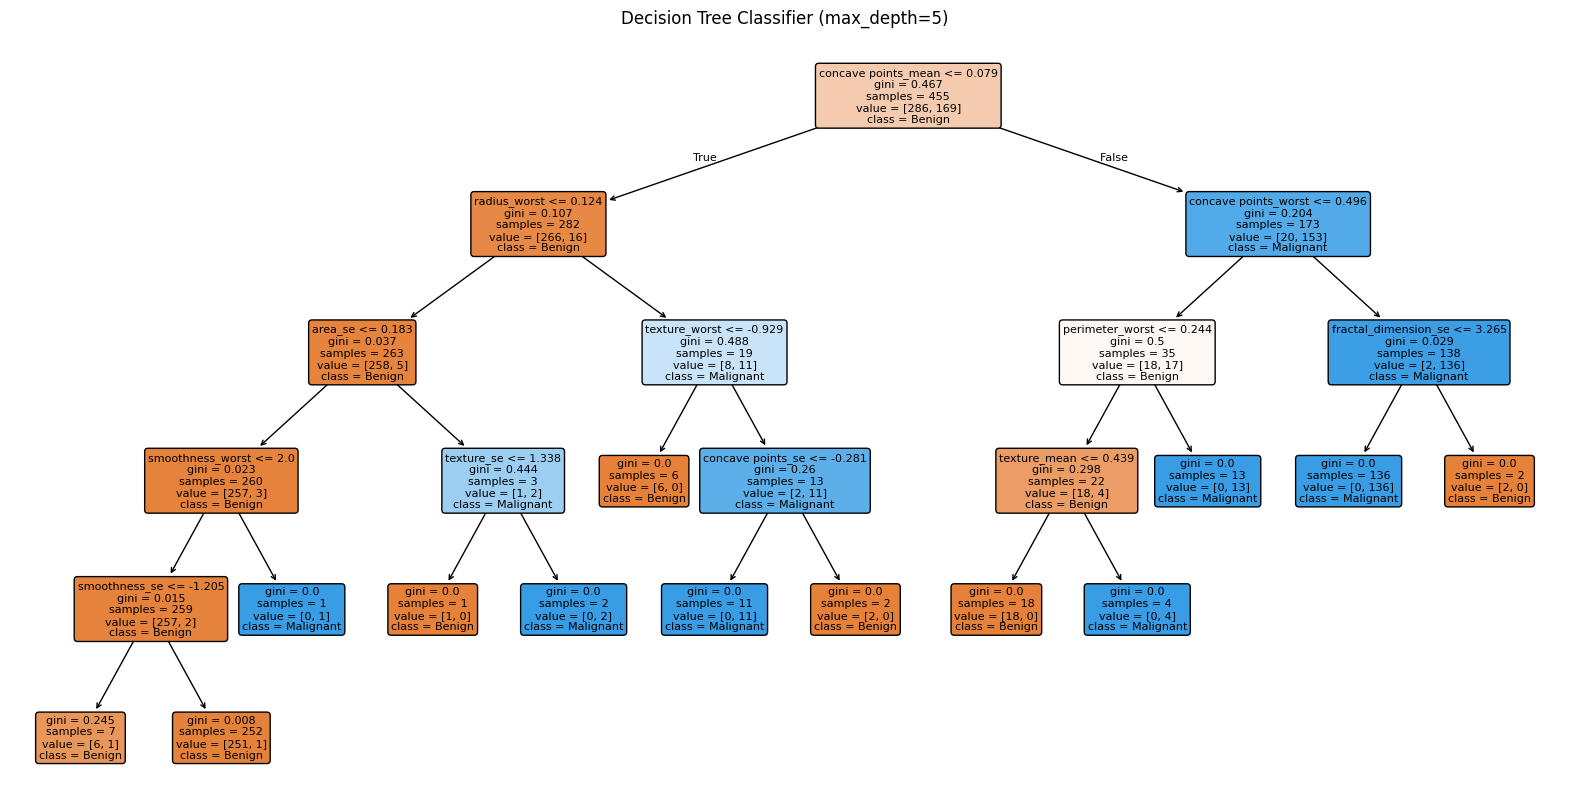


                 Feature  Importance
7    concave points_mean    0.703696
27  concave points_worst    0.066816
20          radius_worst    0.053228
Maximum depth of tree:  5
Nodes of the tree:  25


In [170]:
#Q14. Visualize the Decision Tree:

# Use plot_tree() to display the tree structure
# Identify the top 3 features used for splitting at the first 3 levels
# What is the maximum depth of the tree?
# How many nodes are in the tree? Interpret the decision rules.

from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(
    dt,
    feature_names = X_train.columns,
    class_names=['Benign', 'Malignant'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Classifier (max_depth=5)")
plt.show()
print()


#Identify the top 3 features
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
print(feature_importance.head(3))

print("Maximum depth of tree: ",dt.get_depth())
print("Nodes of the tree: ",dt.tree_.node_count)

In [171]:
#Q15. Apply Hyperparameter Tuning for Decision Tree using GridSearchCV:
# Parameters: max_depth = [3, 5, 7, 10], min_samples_split = [2, 5, 10]
# Use 5-fold Stratified Cross Validation
# Find best parameters
# Evaluate final model
# Do the tuned parameters prevent overfitting? Check training vs testing accuracy.


param_grid ={
    'max_depth': [3,5,7,10],
    'min_samples_split': [2,5,10]
}

dt = DecisionTreeClassifier(random_state=42)

# 5-Fold Stratified Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Grid Search
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

# Train Grid Search
grid_search.fit(X_train_scaled, y_train)

# Best Parameters
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

# Best Model
best_dt = grid_search.best_estimator_

# Predictions
y_pred_dt_tuned = best_dt.predict(X_test_scaled)
y_prob_dt_tuned = best_dt.predict_proba(X_test_scaled)[:,1]


#evaluation

accuracy_dt_tuned = accuracy_score(y_test, y_pred_dt_tuned)
precision_dt_tuned = precision_score(y_test, y_pred_dt_tuned)
recall_dt_tuned = recall_score(y_test, y_pred_dt_tuned)
f1_dt_tuned = f1_score(y_test, y_pred_dt_tuned)
roc_auc_dt_tuned = roc_auc_score(y_test, y_prob_dt_tuned)

print("Accuracy: ", accuracy_dt_tuned)
print("Precision: ", precision_dt_tuned)
print("Recall: ", recall_dt_tuned)
print("F1 Score: ", f1_dt_tuned)
print("ROC-AUC: ", roc_auc_dt_tuned)
print()

print("Classification Report: ", classification_report(y_test, y_pred_dt_tuned))

Best Parameters: {'max_depth': 5, 'min_samples_split': 2}
Best CV Score: 0.9406593406593406
Accuracy:  0.9473684210526315
Precision:  0.9302325581395349
Recall:  0.9302325581395349
F1 Score:  0.9302325581395349
ROC-AUC:  0.9354733049459547

Classification Report:                precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [172]:
#Do the tuned parameters prevent overfitting? Check training vs testing accuracy.
#ANS: The tuned model reduces overfitting by limiting the tree depth to 5 levels. However, the training accuracy (99.56%) is still noticeably higher than the testing accuracy (94.74%), indicating slight overfitting.
# Since the difference is only about 4.8%, the model still generalizes reasonably well to unseen data.

In [173]:
# svm tuned

# Tuned SVM

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

grid_svm = GridSearchCV(
    SVC(probability=True),
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)

best_svm = grid_svm.best_estimator_

print("Best Parameters:", grid_svm.best_params_)

y_pred_svm_tuned = best_svm.predict(X_test_scaled)
y_prob_svm_tuned = best_svm.predict_proba(X_test_scaled)[:,1]

accuracy_svm_tuned = accuracy_score(y_test, y_pred_svm_tuned)
precision_svm_tuned = precision_score(y_test, y_pred_svm_tuned)
recall_svm_tuned = recall_score(y_test, y_pred_svm_tuned)
f1_svm_tuned = f1_score(y_test, y_pred_svm_tuned)
roc_auc_svm_tuned = roc_auc_score(y_test, y_prob_svm_tuned)

print("Accuracy:", accuracy_svm_tuned)
print("Precision:", precision_svm_tuned)
print("Recall:", recall_svm_tuned)
print("F1:", f1_svm_tuned)
print("ROC-AUC:", roc_auc_svm_tuned)

Best Parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Accuracy: 0.9824561403508771
Precision: 1.0
Recall: 0.9534883720930233
F1: 0.9761904761904762
ROC-AUC: 0.99737962659679


Section 5: Model Comparison &amp; Advanced Techniques

In [174]:
#Q16. Compare SVM and Decision Tree using a comprehensive table:

compare = pd.DataFrame({
    "Metric": ['Linear SVM', 'RBF SVM', 'SVM Tuned', 'Decision Tree', 'Decision Tree Tuned'],
    "Accuracy": [accuracy_lsvm, accuracy_rbf, accuracy_svm_tuned, accuracy_dt, accuracy_dt_tuned],
    "Precision":[precision_lsvm, precision_rbf, precision_svm_tuned, precision_dt, precision_dt_tuned],
    "Recall":[recall_lsvm, recall_rbf, recall_svm_tuned, recall_dt, recall_dt_tuned],
    "F1 Score":[f1_lsvm, f1_rbf, f1_svm_tuned ,f1_dt, f1_dt_tuned],
    "roc-auc":[roc_auc_lsvm, roc_auc_rbf, roc_auc_svm_tuned ,roc_auc_dt, roc_auc_dt_tuned]
})
print(compare)

                Metric  Accuracy  Precision    Recall  F1 Score   roc-auc
0           Linear SVM  0.956140   0.931818  0.953488  0.942529  0.996397
1              RBF SVM  0.964912   0.953488  0.953488  0.953488  0.988863
2            SVM Tuned  0.982456   1.000000  0.953488  0.976190  0.997380
3        Decision Tree  0.947368   0.930233  0.930233  0.930233  0.935473
4  Decision Tree Tuned  0.947368   0.930233  0.930233  0.930233  0.935473


In [175]:
# contdd 16 ques, Which model is best for breast cancer diagnosis? Justify your answer.

# Best Model: SVM Tuned

# Justification:

#1. The Tuned SVM model achieved the best overall performance among all models. It obtained the highest accuracy (98.25%), highest precision (100%), highest F1-score (97.62%), and highest ROC-AUC (99.74%). A precision of 100% indicates that every tumor predicted as malignant was actually malignant, which is extremely important in medical diagnosis.
#2. The high ROC-AUC score shows excellent ability to distinguish between benign and malignant tumors.

#Conclusion: Tuned SVM is the most suitable model for breast cancer diagnosis because it provides the highest predictive performance and reliability for identifying malignant cases while minimizing classification errors.

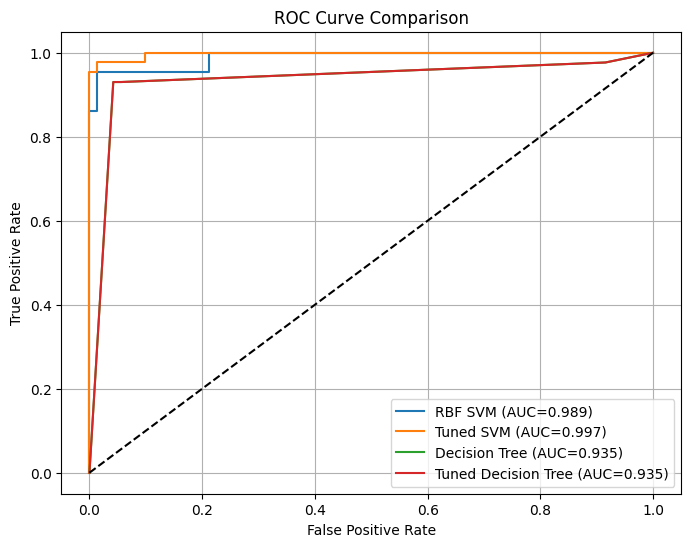

In [176]:
#Q17 Apply ROC Curve and AUC Analysis:

#1. Plot ROC curves for: SVM (RBF), Decision Tree, and Tuned models ---->
#2. Calculate AUC scores for all models

#ANS:

# RBF SVM
fpr_rbf, tpr_rbf, _ = roc_curve(y_test, y_prob_rbf)

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

# Tuned SVM
fpr_svm_tuned, tpr_svm_tuned, _ = roc_curve(y_test, y_prob_svm_tuned)

# Tuned Decision Tree
fpr_dt_tuned, tpr_dt_tuned, _ = roc_curve(y_test, y_prob_dt_tuned)

plt.figure(figsize=(8,6))

plt.plot(fpr_rbf, tpr_rbf,
         label=f'RBF SVM (AUC={roc_auc_rbf:.3f})')


plt.plot(fpr_svm_tuned, tpr_svm_tuned,
         label=f'Tuned SVM (AUC={roc_auc_svm_tuned:.3f})')


plt.plot(fpr_dt, tpr_dt,
         label=f'Decision Tree (AUC={roc_auc_dt:.3f})')


plt.plot(fpr_dt_tuned, tpr_dt_tuned,
         label=f'Tuned Decision Tree (AUC={roc_auc_dt_tuned:.3f})')

plt.plot([0,1],[0,1],'k--')


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()
print()





In [177]:
# contdd to Q17:

#3. Which model has the highest AUC? ---> Tuned SVM

#4. What does AUC >0.95 mean for a medical diagnosis model?
# ANS:
# 1. An AUC greater than 0.95 indicates excellent classification performance.
# 2. It means the model can correctly rank a randomly chosen malignant case higher than a randomly chosen benign case more than 95% of the time.
# 3. For medical diagnosis, this suggests very strong discriminative ability and high reliability.


#5. Why is ROC-AUC important for medical classification?
# ANS:
#1. Evaluates overall model performance across all classification thresholds.
#2. Independent of class imbalance, making it suitable for medical datasets.
#3. In healthcare, minimizing false negatives is critical because missing a cancer case can have serious consequences.
#4. ROC-AUC provides a single metric summarizing how well the model separates diseased and healthy patients.

Section 6: Business Insights &amp; Medical Interpretation

In [178]:
#Q18. Feature Importance Analysis:
# For Decision Tree: Use feature_importances_ to get top 10 most important features
# For SVM: Use coefficient magnitude (for linear) or analyze feature correlations
#Create a table:
#Rank Feature
#Name

#Importance
#Score

#Medical
#Interpretation

#1 ? ? ?
#2 ? ? ?
#3 ? ? ?
#What do these features tell us about breast cancer diagnosis? (e.g., larger radius = more
#likely malignant)

In [179]:
# Step 1: Decision Tree Top 10 Features


feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_dt.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
7,concave points_mean,0.703696
27,concave points_worst,0.066816
20,radius_worst,0.053228
22,perimeter_worst,0.052408
1,texture_mean,0.031355
21,texture_worst,0.028161
19,fractal_dimension_se,0.018884
17,concave points_se,0.016214
13,area_se,0.012195
24,smoothness_worst,0.009397
